<a href="https://colab.research.google.com/github/Prajwala15/Prajwala15/blob/main/Reading_Text_in_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reading Text in Images for Visual Question Answering (TextVQA)

**Team notebook** — all members run their work here in order.

| Member | Section | What you run |
|--------|---------|--------------|
| **Member 1** | OCR pipeline | OCR cache, OCR-first baseline (Flan-T5), error analysis |
| **Member 2** | VLM pipeline | BLIP-2 answers directly from image + question |
| **Member 3** | Hybrid + analysis | VLM + OCR hint, cross-approach comparison |

**Before you start:** Runtime → **GPU** (T4 is fine). Run **Shared setup** first, then your member section.

Use `LIMIT = 200` for a quick test; `LIMIT = 0` for the full val split (5000 questions).

## Shared setup (all members)

In [ ]:
# Clone repo (skip if you uploaded the folder or already cloned)
import os
if os.path.exists('/content'):
    %cd /content
if not os.path.exists('scripts/01_run_ocr.py'):
    !git clone -q https://github.com/Prajwala15/Prajwala15.git textvqa
    %cd textvqa
else:
    print('Using project folder:', os.getcwd())
!ls -la

In [ ]:
# Install dependencies
!apt-get -qq install -y tesseract-ocr tesseract-ocr-eng > /dev/null
!pip install -q -r requirements.txt
!pip install -q paddlepaddle-gpu==2.6.2

In [ ]:
# Download TextVQA data + fix image path in config
import os, yaml, glob
os.makedirs('data', exist_ok=True)
!wget -q -nc -P data https://dl.fbaipublicfiles.com/textvqa/data/TextVQA_0.5.1_val.json
!wget -q -nc -P data https://dl.fbaipublicfiles.com/textvqa/data/TextVQA_0.5.1_train.json

if not glob.glob('data/train_images/**/*.jpg', recursive=True):
    !wget -q -nc -O data/train_val_images.zip https://dl.fbaipublicfiles.com/textvqa/images/train_val_images.zip
    !mkdir -p data/train_images
    !unzip -q data/train_val_images.zip -d data/train_images

candidates = ['data/train_images/train_images', 'data/train_images']
img_dir = next((p for p in candidates if len(glob.glob(p + '/*.jpg')) > 100), candidates[0])
with open('configs/default.yaml') as f:
    cfg = yaml.safe_load(f)
cfg['paths']['images']['train'] = img_dir
cfg['paths']['images']['val'] = img_dir
with open('configs/default.yaml', 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False)
print('Image dir:', img_dir, '| jpg count:', len(glob.glob(img_dir + '/*.jpg')))

In [ ]:
# Global run settings (change here for quick test vs full val)
LIMIT = 200          # 0 = full val (5000); 200 = quick Colab test
ENGINE = 'easyocr'   # easyocr | paddleocr | tesseract  (Member 1)
PREPROCESS = True    # denoise + contrast + deskew
GPU = True

limit_flag = f'--limit {LIMIT}' if LIMIT else ''
pre_flag = '--preprocess' if PREPROCESS else ''
gpu_flag = '--gpu' if GPU else ''

from src.dataset import TextVQADataset
ds = TextVQADataset('val', limit=3)
print('val questions:', len(TextVQADataset('val')))
print('sample question:', ds[0]['question'])
print('sample image size:', ds[0]['image'].size)

---
## Member 1 — OCR pipeline & text extraction

OCR engines, preprocessing, bbox/conf/tokens, OCR+question fusion → Flan-T5, baseline metrics, error analysis.

### 1.1 Run OCR (cache tokens for the team)

In [31]:
import os
p = "outputs/ocr_cache/val_easyocr_preprocessed.json"
if os.path.exists(p):
    os.remove(p)

!python scripts/01_run_ocr.py --split val --engine easyocr --limit 200 --preprocess --gpu --force

OCR[easyocr]: 100% 200/200 [01:15<00:00,  2.66it/s]
wrote outputs/ocr_cache/val_easyocr_preprocessed.json  (126 images)


In [30]:
!python scripts/01_run_ocr.py --split val --engine {ENGINE} {limit_flag} {pre_flag} {gpu_flag}

Traceback (most recent call last):
  File "/content/textvqa/scripts/01_run_ocr.py", line 72, in <module>
    main()
  File "/content/textvqa/scripts/01_run_ocr.py", line 47, in main
    cache = json.load(f)
            ^^^^^^^^^^^^
  File "/usr/lib/python3.12/json/__init__.py", line 293, in load
    return loads(fp.read(),
           ^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/json/__init__.py", line 346, in loads
    return _default_decoder.decode(s)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/json/decoder.py", line 338, in decode
    obj, end = self.raw_decode(s, idx=_w(s, 0).end())
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/json/decoder.py", line 356, in raw_decode
    raise JSONDecodeError("Expecting value", s, err.value) from None
json.decoder.JSONDecodeError: Expecting value: line 1 column 75 (char 74)


In [32]:
# Inspect OCR output: text, confidence, bounding boxes
import json
from src.config import load_config, ocr_cache_path
cfg = load_config()
cfg['ocr']['preprocess'] = PREPROCESS
path = ocr_cache_path(cfg, 'val', ENGINE)
with open(path) as f:
    cache = json.load(f)
sample_id = next(iter(cache))
print('cache:', path)
print('image_id:', sample_id)
print('sample tokens:', cache[sample_id][:5])
print('images with text:', sum(1 for v in cache.values() if v))

cache: outputs/ocr_cache/val_easyocr_preprocessed.json
image_id: 003a8ae2ef43b901
sample tokens: [{'text': 'j2', 'conf': 0.1698592810330764, 'bbox': [635, 0, 712, 96]}, {'text': '01', 'conf': 0.18741950856281145, 'bbox': [638, 75, 707, 195]}]
images with text: 117


### 1.2 OCR-first baseline (OCR + question → Flan-T5)

In [33]:
import yaml
from src.config import load_config
with open('configs/default.yaml') as f:
    disk = yaml.safe_load(f)
disk['ocr']['preprocess'] = PREPROCESS
disk['ocr']['engine'] = ENGINE
with open('configs/default.yaml', 'w') as f:
    yaml.dump(disk, f, default_flow_style=False)
!python scripts/02_eval.py --approach ocr_first --split val {limit_flag} --engine {ENGINE} {pre_flag}

tokenizer_config.json: 100% 2.54k/2.54k [00:00<00:00, 9.34MB/s]
spiece.model: 100% 792k/792k [00:00<00:00, 1.09MB/s]
tokenizer.json: 100% 2.42M/2.42M [00:00<00:00, 81.1MB/s]
special_tokens_map.json: 100% 2.20k/2.20k [00:00<00:00, 10.3MB/s]
config.json: 100% 1.40k/1.40k [00:00<00:00, 6.84MB/s]
model.safetensors: 100% 990M/990M [00:12<00:00, 79.7MB/s]
Loading weights: 100% 282/282 [00:00<00:00, 6782.19it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
generation_config.json: 100% 147/147 [00:00<00:00, 761kB/s]
eval[ocr_first]: 100% 200/200 [00:22<00:00,  8.94it/s]
{
  "n": 200,
  "vqa_accuracy": 0.08,
  "anls": 0.10358333333333332,
  "exact_match": 0.08,
  "f1": 0.08,
  "approach": "ocr_first",
  "split": "val"
}

predictions -> outputs/preds/ocr

In [34]:
import json
with open('outputs/scores/ocr_first_val.json') as f:
    print(json.dumps(json.load(f), indent=2))

{
  "n": 200,
  "vqa_accuracy": 0.08,
  "anls": 0.10358333333333332,
  "exact_match": 0.08,
  "f1": 0.08,
  "approach": "ocr_first",
  "split": "val"
}


### 1.3 Low-confidence OCR error analysis

In [35]:
!python scripts/04_ocr_error_analysis.py --split val --engine {ENGINE} {pre_flag} --conf-threshold 0.5


=== Member 1 OCR error analysis ===
OCR cache: outputs/ocr_cache/val_easyocr_preprocessed.json
Images: 126  |  with text: 117  |  empty: 9
Tokens: 1911  |  low-confidence (<0.5): 1160

OCR-first baseline (n=200):
  VQA accuracy: 0.080
  F1 (exact match): 0.080

saved outputs/member1/low_confidence_tokens.csv
saved outputs/member1/low_confidence_summary.json
saved outputs/member1/low_confidence_examples.png


,question,ocr_text,pred,vqa_acc,f1,ocr_bucket
0,what is the brand of this camera?,,naik,0.0,0.0,none
1,what does the small white text spell?,,None,0.0,0.0,none
2,what kind of beer is this?,882 6 4 em 3 9 3 ( E,em,0.0,0.0,none
3,what brand liquor is on the right?,2 5 0 3 # 8 1 6 8 1,st. johns,0.0,0.0,none
4,how long has the drink on the right been aged?,2 5 0 3 # 8 1 6 8 1,6,0.0,0.0,none
5,what number is on the player's jersey?,&,&,0.0,0.0,none
6,what is the time?,20 AP 16,6:00,0.0,0.0,none
7,what brand of watch is that?,20 AP 16,adria,0.0,0.0,none
8,who is at the center of all of this?,1 j 8 1 } 2,the emperor,0.0,0.0,none
9,who was the photographer?,1,john scott,0.0,0.0,none


Low-confidence tokens: 1160


,image_id,text,conf,bbox
0,003a8ae2ef43b901,j2,0.169859,"[635, 0, 712, 96]"
1,003a8ae2ef43b901,01,0.187420,"[638, 75, 707, 195]"
2,b9dc400eb20bad64,1,0.160317,"[569, -20, 746, 695]"
3,b9dc400eb20bad64,1,0.224622,"[568, 255, 628, 519]"
4,2b538a43dd933fc1,882,0.470324,"[449, 145, 563, 213]"
5,2b538a43dd933fc1,em,0.356670,"[448, 208, 526, 240]"
6,2b538a43dd933fc1,0,0.134345,"[517, 191, 559, 237]"
7,2b538a43dd933fc1,9,0.453491,"[44, 412, 94, 524]"
8,2b538a43dd933fc1,76,0.247300,"[90, 630, 150, 682]"
9,2b538a43dd933fc1,1,0.192254,"[117, 259, 344, 777]"


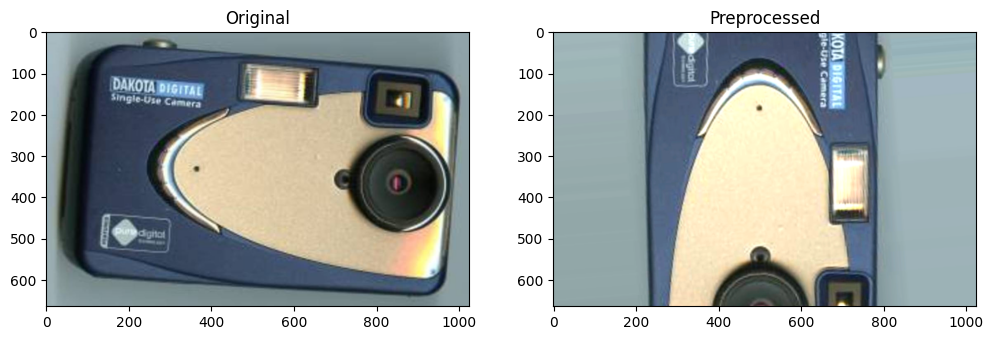

In [36]:
# Member 1 deliverables: predictions table + low-confidence tokens
import json, pandas as pd
from IPython.display import display
rows = json.load(open('outputs/preds/ocr_first_val.json'))
df = pd.DataFrame(rows)[['question', 'ocr_text', 'pred', 'vqa_acc', 'f1', 'ocr_bucket']]
display(df.head(10))
low = pd.read_csv('outputs/member1/low_confidence_tokens.csv')
print('Low-confidence tokens:', len(low))
display(low.head(10))

# Preprocessing before/after (one image)
from src.preprocess import preprocess_image
import matplotlib.pyplot as plt
from src.dataset import TextVQADataset
raw = TextVQADataset('val', limit=1)[0]['image']
proc = preprocess_image(raw)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(raw); ax[0].set_title('Original')
ax[1].imshow(proc); ax[1].set_title('Preprocessed')
plt.show()

---
## Member 2 — Vision-language model (VLM)

Answer directly from **image + question** using BLIP-2 (no OCR at inference).

**Note:** Member 1 OCR cache is not required for this section.

In [37]:
!python scripts/02_eval.py --approach vlm --split val {limit_flag}

processor_config.json: 100% 68.0/68.0 [00:00<00:00, 344kB/s]
preprocessor_config.json: 100% 432/432 [00:00<00:00, 2.48MB/s]
config.json: 100% 2.22k/2.22k [00:00<00:00, 8.11MB/s]
tokenizer_config.json: 100% 21.0k/21.0k [00:00<00:00, 34.8MB/s]
spiece.model: 100% 792k/792k [00:01<00:00, 737kB/s]
tokenizer.json: 100% 2.42M/2.42M [00:00<00:00, 81.3MB/s]
added_tokens.json: 100% 23.0/23.0 [00:00<00:00, 153kB/s]
special_tokens_map.json: 100% 2.54k/2.54k [00:00<00:00, 11.7MB/s]
model.safetensors.index.json: 100% 128k/128k [00:00<00:00, 231MB/s]
Fetching 2 files: 100% 2/2 [02:02<00:00, 61.16s/it] 
Download complete: 100% 15.8G/15.8G [02:02<00:00, 129MB/s]
Loading weights: 100% 1289/1289 [00:54<00:00, 23.56it/s]
[transformers] The tied weights mapping and config for this model specifies to tie language_model.shared.weight to language_model.lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=

In [ ]:
import json, pandas as pd
from IPython.display import display
with open('outputs/scores/vlm_val.json') as f:
    print('VLM scores:', json.dumps(json.load(f), indent=2))
rows = json.load(open('outputs/preds/vlm_val.json'))
display(pd.DataFrame(rows)[['question', 'pred', 'vqa_acc', 'f1', 'ocr_bucket']].head(10))

---
## Member 3 — Hybrid pipeline & cross-approach analysis

Hybrid uses **OCR tokens as a hint** to the VLM. Requires **Member 1 OCR cache**.

Then compare all three approaches by OCR quality bucket.

In [ ]:
import yaml
from src.config import load_config
with open('configs/default.yaml') as f:
    disk = yaml.safe_load(f)
disk['ocr']['preprocess'] = PREPROCESS
disk['ocr']['engine'] = ENGINE
with open('configs/default.yaml', 'w') as f:
    yaml.dump(disk, f, default_flow_style=False)
!python scripts/02_eval.py --approach hybrid --split val {limit_flag} --engine {ENGINE} {pre_flag}

In [ ]:
import json
with open('outputs/scores/hybrid_val.json') as f:
    print('Hybrid scores:', json.dumps(json.load(f), indent=2))

### 3.1 Compare OCR-first vs VLM vs Hybrid

In [ ]:
!python scripts/03_analysis.py --split val

In [ ]:
import pandas as pd
from IPython.display import display, Image
df = pd.read_csv('outputs/comparison_val.csv')
display(df)
display(Image(filename='outputs/comparison_val.png'))